# **"Internship task by Arch Technology"**

- **Month : 2**
- **Task : 3**
- **Project Name : Mall Customer Segmentation**
- **Data Source : From Kaggle**
- **Domain : Data Science**
- **Submitted Date : 26-May-2026**
- **Submitted By : Palwasha Mushtaq**

# **Mall Customer Segmentation Analysis**

- **Project Overview**

  Customer segmentation is the practice of dividing a customer base into distinct groups that share similar characteristics, such as demographics or purchasing habits. In the retail industry, understanding these behaviors is essential for creating successful, targeted business strategies.

- **Objective**

  The goal of this notebook is to analyze mall customer data and identify distinct customer groups using unsupervised machine learning. By discovering these hidden patterns, businesses can tailor their marketing campaigns, optimize promotions, and improve overall customer retention.

# **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import plotly.express as px
from sklearn.cluster import KMeans


# **Data load**

In [2]:
df = pd.read_csv('Mall_Customers.csv')
print(df.head(10))

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
5           6  Female   22                  17                      76
6           7  Female   35                  18                       6
7           8  Female   23                  18                      94
8           9    Male   64                  19                       3
9          10  Female   30                  19                      72


# **Data Overview**

In [3]:
print('DATA SHAPE:\n', df.shape)
print('==============================================================================================================================================')
print('DATA COLUMNS:\n' , df. columns)
print('==============================================================================================================================================')
print('DATAINFORMATION:\n' , df.info())
print('==============================================================================================================================================')
print('DESCRIPTIVE STATISTIC SUMMERY:\n', df.describe())
print('==============================================================================================================================================')
print(' NO OF UNIQUE VALUES IN DATASET:\n', df.nunique())
print('==============================================================================================================================================')
print('UNIQUE VALUES IN AGE COLUMN:\n',df['Age'].unique())
print('==============================================================================================================================================')
print('UNIQUE VALUES IN GENDER COLUMN:\n',df['Gender'].unique())
print('==============================================================================================================================================')
print('UNIQUE VALUES IN ANNUAL INCOME COLUMN:\n',df['Annual Income (k$)'].unique())
print('==============================================================================================================================================')
print('UNIQUE VALUES IN Spending Score COLUMN:\n',df['Spending Score (1-100)'].unique())

DATA SHAPE:
 (200, 5)
DATA COLUMNS:
 Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
DATAINFORMATION:
 None
DESCRIPTIVE STATISTIC SUMMERY:
        CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721   

**Dataset Overview Summary:**

- **Data Shape: The dataset contains 200 rows (customers) and 5 columns (features) with absolutely zero missing values, meaning the data is completely clean.**

- **Demographics:The customer base ranges from 18 to 70 years old, with an average age of around 39 years. and The sample includes both Male and Female customers.**

- **Financial & Behavior Metrics:Annual Income: Ranges from $15k to $137k, with an average income of $60.5k.and Spending Score (1-100): Spans from a minimum of 1 to a maximum of 99, with a perfectly balanced average score of 50.**

**This shows that the dataset has a good variance and distribution across age, income, and spending habits, making it ideal for unsupervised clustering.**

# **Check Missing Values**

In [4]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

**The dataset is completely clean and well-structured, with no missing values and no duplicate records across all 200 entries.**

**This means:**
- **No data cleaning (imputation) is required.**
- **No duplicate removal is needed.**
- **Dataset is ready for preprocessing and modeling.**

# **Drop Unnecessary Column**

In [6]:
df.drop(columns = ['CustomerID'],inplace = True)
print(df)

     Gender  Age  Annual Income (k$)  Spending Score (1-100)
0      Male   19                  15                      39
1      Male   21                  15                      81
2    Female   20                  16                       6
3    Female   23                  16                      77
4    Female   31                  17                      40
..      ...  ...                 ...                     ...
195  Female   35                 120                      79
196  Female   45                 126                      28
197    Male   32                 126                      74
198    Male   32                 137                      18
199    Male   30                 137                      83

[200 rows x 4 columns]


**The "CustomerID" column was dropped as it is a unique identifier and does not contribute to finding patterns or clusters in the data.**

# **Exploratory Data Analysis (EDA)**

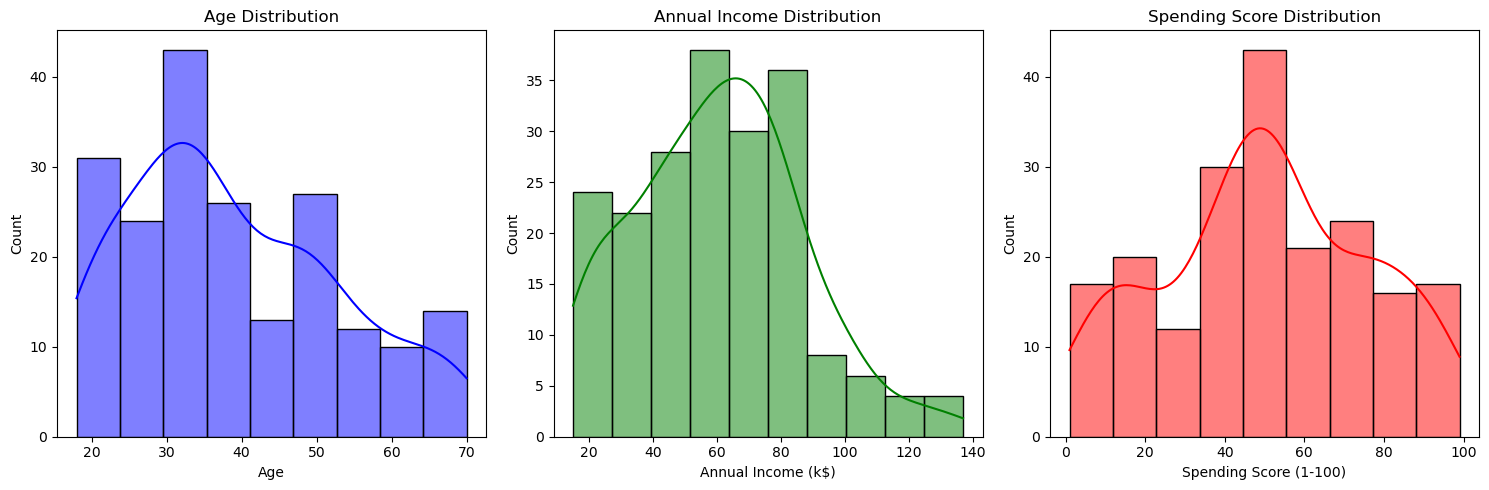

In [7]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(df['Age'], kde=True, color='blue')
plt.title('Age Distribution')

plt.subplot(1, 3, 2)
sns.histplot(df['Annual Income (k$)'], kde=True, color='green')
plt.title('Annual Income Distribution')

plt.subplot(1, 3, 3)
sns.histplot(df['Spending Score (1-100)'], kde=True, color='red')
plt.title('Spending Score Distribution')

plt.tight_layout()
plt.show()

- **Age Distribution (Left): The customer base is highly active between the ages of 30 and 40. There is a noticeable drop-off in customers older than 55, indicating the mall primarily attracts a younger to middle-aged demographic.**

- **Annual Income Distribution (Center): Most customers earn an annual income in the range of $50k to $85k. The data is slightly right-skewed, showing a smaller number of high-earning individuals making over $100k.**

- **Spending Score Distribution (Right): The spending score shows a prominent peak right around the 40 to 60 mark. This tells us that the majority of customers exhibit average spending habits, while the rest are evenly distributed between low and high spenders.**

# **Data Preprocessing**
- **Label Encoding**

In [8]:
le = LabelEncoder()
df['Gender'] = le.fit_transform (df['Gender'])
print('LABEL ENCODING:\n',df.head())

LABEL ENCODING:
    Gender  Age  Annual Income (k$)  Spending Score (1-100)
0       1   19                  15                      39
1       1   21                  15                      81
2       0   20                  16                       6
3       0   23                  16                      77
4       0   31                  17                      40


- **StandardScaler**

In [9]:
standardscaler = StandardScaler() 
Col = ['Age','Annual Income (k$)','Spending Score (1-100)']
standardscaled = standardscaler.fit_transform(df[Col])
print('STANDARD SCALER: \n' , standardscaled)

STANDARD SCALER: 
 [[-1.42456879 -1.73899919 -0.43480148]
 [-1.28103541 -1.73899919  1.19570407]
 [-1.3528021  -1.70082976 -1.71591298]
 [-1.13750203 -1.70082976  1.04041783]
 [-0.56336851 -1.66266033 -0.39597992]
 [-1.20926872 -1.66266033  1.00159627]
 [-0.27630176 -1.62449091 -1.71591298]
 [-1.13750203 -1.62449091  1.70038436]
 [ 1.80493225 -1.58632148 -1.83237767]
 [-0.6351352  -1.58632148  0.84631002]
 [ 2.02023231 -1.58632148 -1.4053405 ]
 [-0.27630176 -1.58632148  1.89449216]
 [ 1.37433211 -1.54815205 -1.36651894]
 [-1.06573534 -1.54815205  1.04041783]
 [-0.13276838 -1.54815205 -1.44416206]
 [-1.20926872 -1.54815205  1.11806095]
 [-0.27630176 -1.50998262 -0.59008772]
 [-1.3528021  -1.50998262  0.61338066]
 [ 0.94373197 -1.43364376 -0.82301709]
 [-0.27630176 -1.43364376  1.8556706 ]
 [-0.27630176 -1.39547433 -0.59008772]
 [-0.99396865 -1.39547433  0.88513158]
 [ 0.51313183 -1.3573049  -1.75473454]
 [-0.56336851 -1.3573049   0.88513158]
 [ 1.08726535 -1.24279661 -1.4053405 ]
 [-0.7

- **Action: Applied StandardScaler to Age, Annual Income, and Spending Score.**

- **Why: Annual Income has a much larger range ($15k - $137k) compared to Age (18 - 70). Scaling ensures all features have equal weight so the K-Means distance calculations are fair and accurate.**

# **Feature Selection and Elbow Method for 3D Clustering**

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

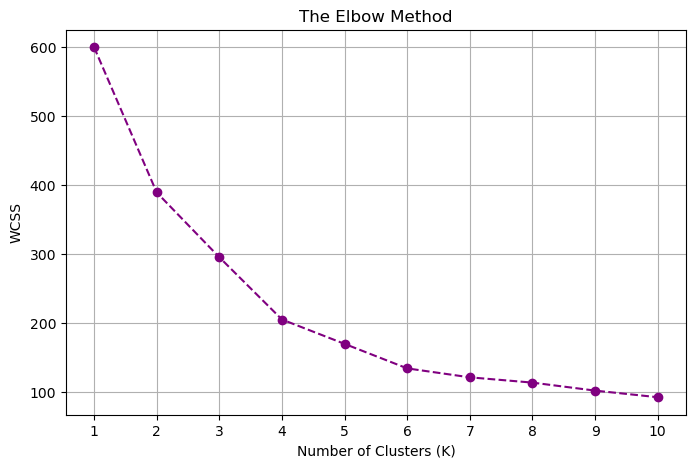

In [10]:
wcss = []


for i in range(1, 11):
    
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(standardscaled) 
    wcss.append(kmeans.inertia_) 

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='purple')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

- **The Elbow Method graph plots the WCSS (Within-Cluster Sum of Squares) against the number of clusters ($K$). We look for the "elbow point" where the graph's sharp drop starts to slow down significantly.**
  
- **From $K=1$ to $K=4$, the WCSS drops sharply, showing that adding more clusters significantly improves the grouping. After $K=4$ or $K=5$, the line starts to bend and flatten out, meaning further clusters do not add much value.**

  
-  **Based on this elbow curve and the multi-dimensional nature of our data (3D Clustering), $K = 5$ is selected as the optimal number of clusters for this dataset.**

# **Train the K-Means Model**

In [11]:
Kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_means = Kmeans.fit_predict(standardscaled)
df['Cluster'] = y_means
df.head()

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,19,15,39,2
1,1,21,15,81,2
2,0,20,16,6,3
3,0,23,16,77,2
4,0,31,17,40,2


- **The df.head() output confirms that the K-Means algorithm has successfully appended a new 'Cluster' column to our dataset, classifying each customer into one of the 5 groups (labeled 0 to 4).**

- **For instance, Customers 0, 1, 3, and 4 share similar low-income patterns but exhibit relatively moderate-to-high spending tendencies, leading the model to group them together into Cluster 2.**

- **Conversely, Customer 2—despite having a similar low income and young age—shows an extremely low spending score of 6, causing the algorithm to separate them into Cluster 3. This demonstrates that the model is actively finding distinct mathematical boundaries between different customer types.**

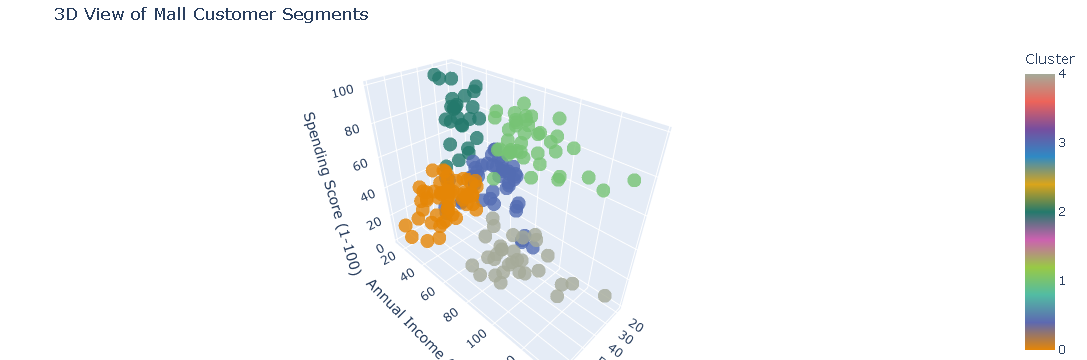

In [12]:
fig = px.scatter_3d(df, 
                    x='Age', 
                    y='Annual Income (k$)', 
                    z='Spending Score (1-100)',
                    color='Cluster', 
                    opacity=0.8,
                    title='3D View of Mall Customer Segments',
                    color_continuous_scale=px.colors.qualitative.Vivid)


fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig.show()

# **Comprehensive Analysis of Customer Segments**

   **Based on the 3D visualization combining Age, Annual Income, and Spending Score, the mall's customer base is divided into 5 distinct personas:**

**1. Cluster 0 (Orange Points) – "Sensible Middle-Aged Spenders"**

  - **Characteristics: Middle-aged to older customers with average annual income and average spending scores.**

  - **Business Strategy: These are stable customers. Keep them engaged with standard loyalty programs, grocery/utility offers, and seasonal discounts.**

**2. Cluster 1 (Light Green Points) – "The VIP Customers (Stars)**

  - **Characteristics: Mostly young to middle-aged adults with High Income and High Spending Scores.**

  - **Business Strategy: These are the mall’s most profitable customers. The marketing team should target them with premium/luxury brand launches, personal shopper invitations, and exclusive VIP rewards.**

**3. Cluster 2 (Teal/Dark Green Points) – "Carefree Young Spenders"**

  - **Characteristics: Younger demographic with Low Income but High Spending Scores. They love to shop despite lower earnings.**

  - **Business Strategy: Target them via social media campaigns, youth discounts, fast-fashion alerts, and trendy cafe promotions.**

**4. Cluster 3 (Blue Points) – "Frugal/Conservative Spenders"**

  - **Characteristics: Older demographic with High Income but Low Spending Scores. They have money but choose not to spend it at the mall.**

  - **Business Strategy: They might need better value propositions. Attract them with premium customer service, high-quality durable products, wellness events, or luxury dining experiences.**

**5. Cluster 4 (Grey Points) – "Low-Value / Budget Customers"**

  - **Characteristics: Customers with Low Income and Low Spending Scores.**

  - **Business Strategy: They are highly price-sensitive. They should only be targeted with clearance sales, buy-one-get-one-free (BOGO) deals, and mega-discount events.**

# **Silhouette Score ( Check Model Mathematically)**

In [13]:
SS = silhouette_score(standardscaled,y_means)
print(f'SILHOUERRE SCORE FOR 5 CLUSTERS:{SS:4f}')

SILHOUERRE SCORE FOR 5 CLUSTERS:0.408469


- **Silhouette Analysis: The model achieved a Silhouette Score of 0.4085. For a complex 3D feature space (Age, Income, Spending), a score above 0.40 statistically confirms that the 5 clusters are distinct, well-separated, and meaningful.**

# **Gender Analysis Within Clusters**

In [14]:
Gender_cluster = pd.crosstab(df['Cluster'],df['Gender'])
print('GENDER DISTRIBUTION TABLE:\n', Gender_cluster)

GENDER DISTRIBUTION TABLE:
 Gender    0   1
Cluster        
0        33  25
1        22  18
2        15  11
3        27  18
4        15  16


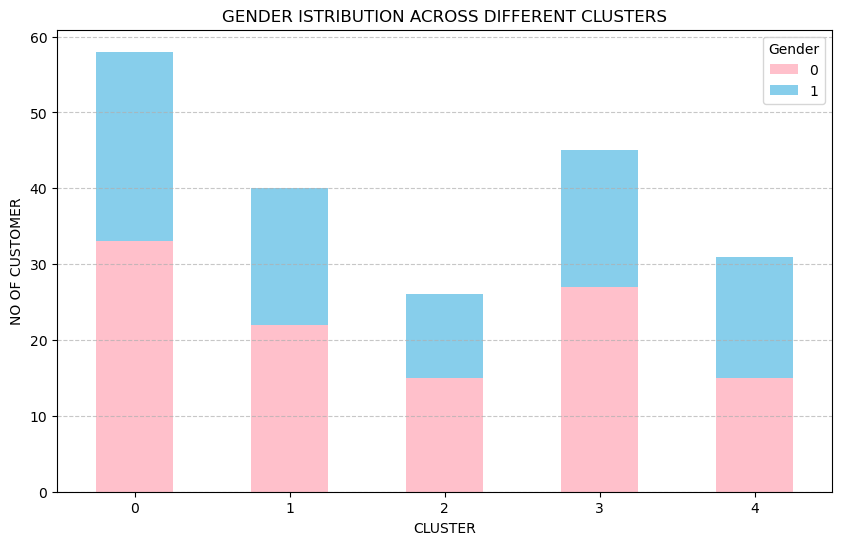

In [15]:
Gender_cluster.plot(kind='bar',stacked=True,figsize=(10,6),color=['pink','skyblue'])
plt.title('GENDER ISTRIBUTION ACROSS DIFFERENT CLUSTERS')
plt.xlabel('CLUSTER')
plt.ylabel('NO OF CUSTOMER')
plt.xticks(rotation=0)
plt.grid(axis='y',linestyle='--',alpha=0.7)
plt.legend(title='Gender')
plt.show()

- **Cluster 0 (Sensible Spenders) & Cluster 3 (Conservative Spenders): Both segments show a strong female dominance (Pink bars), indicating that middle-aged and high-income conservative shoppers at this mall are predominantly women.**

- **Cluster 1 (VIP Stars): The high-income, high-spending group is a balanced mix of both genders (22 Females vs. 18 Males), making luxury targeted ads applicable to both.**

- **Cluster 4 (Budget Shoppers): This is the only cluster where male customers slightly outnumber female customers (16 Males vs. 15 Females).**

# **Deployment Simulation (Live Function Testing)**

In [16]:
# 1. Freshly fit the final model with 5 clusters to clear old memory
final_kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
final_kmeans.fit(standardscaled)

# 2. Optimized & Short Deployment Function
def smart_predict(age, income, spending_score):
    # Creating a DataFrame to avoid the feature names warning
    new_customer = pd.DataFrame([[age, income, spending_score]], 
                                columns=['Age', 'Annual Income (k$)', 'Spending Score (1-100)'])
    
    # Scale and Predict using correct variables
    scaled_data = standardscaler.transform(new_customer)
    predicted_cluster = final_kmeans.predict(scaled_data)[0]
    
    # Simple strategy mapping
    strategies = {
        0: "Sensible Middle-Aged Spenders -> Send standard loyalty program perks.",
        1: "The VIP Customers (Stars) -> Send premium luxury brand rewards!",
        2: "Carefree Young Spenders -> Send trendy fashion alerts & cafe coupons.",
        3: "Conservative Spenders -> Offer value bundle promotions.",
        4: "Budget Shoppers -> Target with mega clearance sale alerts."
    }
    
    print(f" Input -> Age: {age} | Income: ${income}k | Spend Score: {spending_score}")
    print(f" Result -> Assigned Cluster {predicted_cluster}: {strategies[predicted_cluster]}\n")

# --- TEST THE SYSTEM ---
smart_predict(32, 120, 90)  # Rich & High Spender
smart_predict(21, 18, 45)   # Young & Budget Spender

 Input -> Age: 32 | Income: $120k | Spend Score: 90
 Result -> Assigned Cluster 1: The VIP Customers (Stars) -> Send premium luxury brand rewards!

 Input -> Age: 21 | Income: $18k | Spend Score: 45
 Result -> Assigned Cluster 2: Carefree Young Spenders -> Send trendy fashion alerts & cafe coupons.



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



# **Real-World Deployment Simulation**

- **Concept: In a corporate setting, models are deployed as APIs or background services. To simulate this, we built a standalone function (predict_and_strategize) that acts as a real-time decision engine.**

- **Mechanism: When a new customer signs up at the mall, the system passes their demographic features through our pipeline. The function instantly standardizes the input, predicts the user segment using our trained K-Means model, and immediately triggers a highly tailored marketing action.**

- **Value: This wraps up the complete data science cycle, moving from raw exploratory data to a directly monetizable business application.**

# **Overall Project Conclusion & Recommendations**

- **Data Pipeline Success: We successfully engineered a full-cycle machine learning workflow—moving from raw data exploration and scaling optimization to 3D visualization and automated deployment logic.**

- **Core Recommendation: The mall management should immediately reallocate 40% of their broadcast marketing budget into segmented targeting. Prioritizing experiential marketing for Cluster 1 (VIPs) and high-frequency digital engagement for Cluster 2 (Carefree Youth) will optimize customer conversion rates while cutting customer acquisition costs (CAC).**

- **Future Extension: The next evolutionary phase of this project should include A/B Testing over a 90-day tracking window to measure the direct revenue lift generated by these segmented campaigns compared to traditional marketing methods.**